In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np
import pandas as pd
from src.features import cycle_day_month
from src._xgboost import search_params
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def process_data(data: pd.DataFrame, start_date: str):
    df = data.copy()
    df = df.asfreq('D')
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def plot_forecast(y_true, y_pred, title="Прогноз vs Истинные значения"):
    """
    Строит график сравнения истинных значений и прогноза
    """
    plt.figure(figsize=(12, 5))
    
    plt.plot(y_true.index, y_true.values, label='Истинные', color='blue', linewidth=1.5)
    plt.plot(y_pred.index, y_pred.values, label='Прогноз', color='red', linestyle='--', linewidth=1.5)
    
    plt.xlabel('Дата')
    plt.ylabel('Значение')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [4]:
start_date = '2020-11-27'

df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full, start_date)
df_train = process_data(df_train, start_date)
df_val = process_data(df_val, start_date)
df_test = process_data(df_test, start_date)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [7]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-08 14:25:16,916] A new study created in memory with name: no-name-4929ecd2-2f41-45f4-8818-d5a46a6c0cd4
[I 2026-05-08 14:25:17,286] Trial 0 finished with value: 10.029726150435945 and parameters: {'lags': 28, 'n_estimators': 370, 'learning_rate': 0.029713837010114666, 'max_depth': 7, 'subsample': 0.5529345246131869, 'colsample_bytree': 0.7475701710715299, 'colsample_bylevel': 0.7066215191340615, 'colsample_bynode': 0.5782225462878805, 'reg_alpha': 5.0126378271330685, 'reg_lambda': 0.009219063319545624, 'gamma': 7.600822803302418, 'min_child_weight': 8, 'max_delta_step': 1}. Best is trial 0 with value: 10.029726150435945.
[I 2026-05-08 14:25:17,701] Trial 1 finished with value: 8.510543961216458 and parameters: {'lags': 19, 'n_estimators': 1292, 'learning_rate': 0.05998946525636504, 'max_depth': 1, 'subsample': 0.45553692930075695, 'colsample_bytree': 0.572251306150791, 'colsample_bylevel': 0.7366495198379232, 'colsample_bynode': 0.5240698842048968, 'reg_alpha': 6.376172565056

Лучшие параметры = {'lags': 12, 'n_estimators': 933, 'learning_rate': 0.01280908523993826, 'max_depth': 16, 'subsample': 0.7666761129343735, 'colsample_bytree': 0.8379748740665589, 'colsample_bylevel': 0.4211448621782161, 'colsample_bynode': 0.6259509577550884, 'reg_alpha': 0.010197474595845551, 'reg_lambda': 8.207710232473389, 'gamma': 1.0533725162571959, 'min_child_weight': 15, 'max_delta_step': 2}
Лучший RMSE score = 2.7468449475126446


Глубина 5

In [18]:
depth = 5
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [19]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-08 14:35:53,636] A new study created in memory with name: no-name-2359463e-0497-494a-a49d-a51c116a74fd
[I 2026-05-08 14:35:54,820] Trial 0 finished with value: 0.6306363775973162 and parameters: {'lags': 30, 'n_estimators': 2163, 'learning_rate': 0.07704933171869789, 'max_depth': 9, 'subsample': 0.6670420279125762, 'colsample_bytree': 0.5195818753503744, 'colsample_bylevel': 0.7000415950131051, 'colsample_bynode': 0.9694083695857197, 'reg_alpha': 0.0006370129484770086, 'reg_lambda': 3.8879213866010606e-05, 'gamma': 0.0013004284796760532, 'min_child_weight': 20, 'max_delta_step': 2}. Best is trial 0 with value: 0.6306363775973162.
[I 2026-05-08 14:35:55,605] Trial 1 finished with value: 1.3570781714302542 and parameters: {'lags': 13, 'n_estimators': 2604, 'learning_rate': 0.673063830265951, 'max_depth': 8, 'subsample': 0.4236690097033864, 'colsample_bytree': 0.4515830753712912, 'colsample_bylevel': 0.5207267454941864, 'colsample_bynode': 0.743795554009173, 'reg_alpha': 0.5136

Лучшие параметры = {'lags': 25, 'n_estimators': 2035, 'learning_rate': 0.0026746501714636803, 'max_depth': 10, 'subsample': 0.5862326968524025, 'colsample_bytree': 0.4559613004015399, 'colsample_bylevel': 0.516812458906932, 'colsample_bynode': 0.7181651280786563, 'reg_alpha': 0.00021540900013708138, 'reg_lambda': 1.492999714951219e-09, 'gamma': 2.3223464295752847e-10, 'min_child_weight': 10, 'max_delta_step': 13}
Лучший RMSE score = 0.22666939368139324


Глубина 10

In [32]:
depth = 10
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [33]:
study = search_params(df_train, df_val, exog_cols, target_col)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-08 15:10:32,262] A new study created in memory with name: no-name-85100fa6-f632-4d46-9ed3-c54de1238861
[I 2026-05-08 15:10:34,525] Trial 0 finished with value: 0.7074430391434985 and parameters: {'lags': 23, 'n_estimators': 2538, 'learning_rate': 0.11540979931658071, 'max_depth': 15, 'subsample': 0.5430752976647845, 'colsample_bytree': 0.8861384862678497, 'colsample_bylevel': 0.7419758605629628, 'colsample_bynode': 0.9603127205997445, 'reg_alpha': 0.018321430641929804, 'reg_lambda': 22.055761560655803, 'gamma': 2.117812310725428e-06, 'min_child_weight': 9, 'max_delta_step': 16}. Best is trial 0 with value: 0.7074430391434985.
[I 2026-05-08 15:10:34,874] Trial 1 finished with value: 0.752451060631787 and parameters: {'lags': 13, 'n_estimators': 817, 'learning_rate': 0.3101673057284291, 'max_depth': 6, 'subsample': 0.5206055663643183, 'colsample_bytree': 0.5697785631908554, 'colsample_bylevel': 0.6064559264328073, 'colsample_bynode': 0.7483955499895503, 'reg_alpha': 3.93320886

Лучшие параметры = {'lags': 21, 'n_estimators': 2090, 'learning_rate': 0.02825803930046176, 'max_depth': 23, 'subsample': 0.4488380760960871, 'colsample_bytree': 0.6727762423471396, 'colsample_bylevel': 0.8633445766491281, 'colsample_bynode': 0.6444804231933567, 'reg_alpha': 5.57635806395788e-10, 'reg_lambda': 1.6082997672223851e-09, 'gamma': 1.4149570881327338e-09, 'min_child_weight': 28, 'max_delta_step': 14}
Лучший RMSE score = 0.2467077129956625


In [38]:
best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
best_model.fit(
            y=df_train_full[target_col],
            exog=df_train_full[exog_cols],
        )

joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_10']

RMSE на тесте = 1.5822793540901932


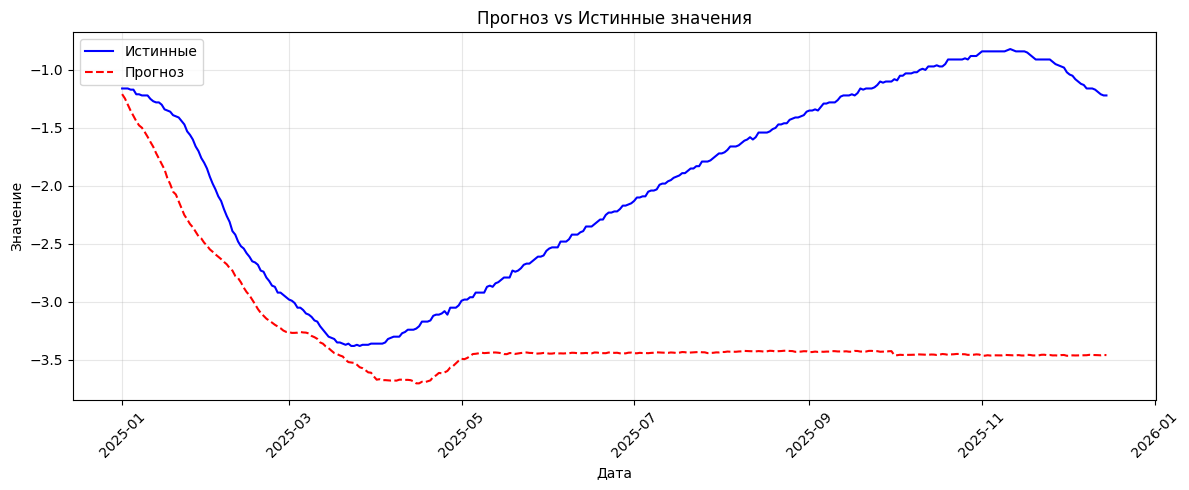

In [39]:
model = joblib.load(model_path)
#last_window = df_train_full[target_col].iloc[-len(model.lags):]
y_pred = model.predict(
            steps=len(df_test),
            exog=df_test[exog_cols]
        )

rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
print(f'RMSE на тесте = {rmse}')

plot_forecast(df_test[target_col], y_pred)

In [17]:
importances = model.get_feature_importances()
importances

,feature,importance
5,lag_6,0.133995
1,lag_2,0.124043
4,lag_5,0.121167
3,lag_4,0.113184
6,lag_7,0.103653
2,lag_3,0.092862
0,lag_1,0.074655
7,lag_8,0.050809
8,lag_9,0.045635
9,lag_10,0.045188
